In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
X, y = make_classification(n_samples=500, n_features=6, random_state=42)

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])

df["target"] = y

df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,target
0,0.127757,0.006742,0.056822,0.097391,0.538296,1.072507,1
1,0.502679,-0.089785,1.443236,0.733431,-0.160133,0.671340,1
2,-0.678286,-0.014150,-0.528639,-0.582239,-0.348652,-0.349258,0
3,0.346622,-0.147021,1.887663,0.762018,1.901191,-0.060661,1
4,1.201539,0.186006,-0.751209,0.546777,-2.121855,-0.607822,0
...,...,...,...,...,...,...,...
495,-0.077458,-0.185429,1.867130,0.487002,-0.033230,-0.208117,1
496,1.082279,0.195718,-0.972083,0.407670,-0.488849,-1.119617,0
497,-1.295802,0.015428,-1.455155,-1.240165,0.321357,0.421921,0
498,-1.350582,0.016209,-1.518026,-1.292983,-0.718407,0.894924,0


In [4]:
print(df.head())
print()
print(df.tail())

   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  target
0   0.127757   0.006742   0.056822   0.097391   0.538296   1.072507       1
1   0.502679  -0.089785   1.443236   0.733431  -0.160133   0.671340       1
2  -0.678286  -0.014150  -0.528639  -0.582239  -0.348652  -0.349258       0
3   0.346622  -0.147021   1.887663   0.762018   1.901191  -0.060661       1
4   1.201539   0.186006  -0.751209   0.546777  -2.121855  -0.607822       0

     feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  target
495  -0.077458  -0.185429   1.867130   0.487002  -0.033230  -0.208117       1
496   1.082279   0.195718  -0.972083   0.407670  -0.488849  -1.119617       0
497  -1.295802   0.015428  -1.455155  -1.240165   0.321357   0.421921       0
498  -1.350582   0.016209  -1.518026  -1.292983  -0.718407   0.894924       0
499  -0.769765  -0.348639   2.887575   0.340693   0.560919  -0.295480       1


In [5]:
df["target"].value_counts()

target
1    252
0    248
Name: count, dtype: int64

In [6]:
df.shape

(500, 7)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_0  500 non-null    float64
 1   feature_1  500 non-null    float64
 2   feature_2  500 non-null    float64
 3   feature_3  500 non-null    float64
 4   feature_4  500 non-null    float64
 5   feature_5  500 non-null    float64
 6   target     500 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 27.5 KB


In [8]:
df.describe()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,-0.043556,-0.010278,0.064305,-0.009175,0.037627,0.074700,0.504000
std,1.296315,0.194427,1.400326,0.862080,0.955300,1.038807,0.500485
min,-4.887584,-0.825560,-3.601671,-2.969014,-2.703232,-2.940389,0.000000
25%,-0.958603,-0.105818,-1.010593,-0.616449,-0.611936,-0.650341,0.000000
50%,0.009359,0.000226,0.040939,0.033570,0.030093,0.076429,1.000000
75%,0.934676,0.166340,1.137192,0.701924,0.682541,0.749506,1.000000
max,3.311449,0.472358,3.778560,1.846496,2.644343,3.193108,1.000000


In [9]:
df.duplicated().sum()

np.int64(0)

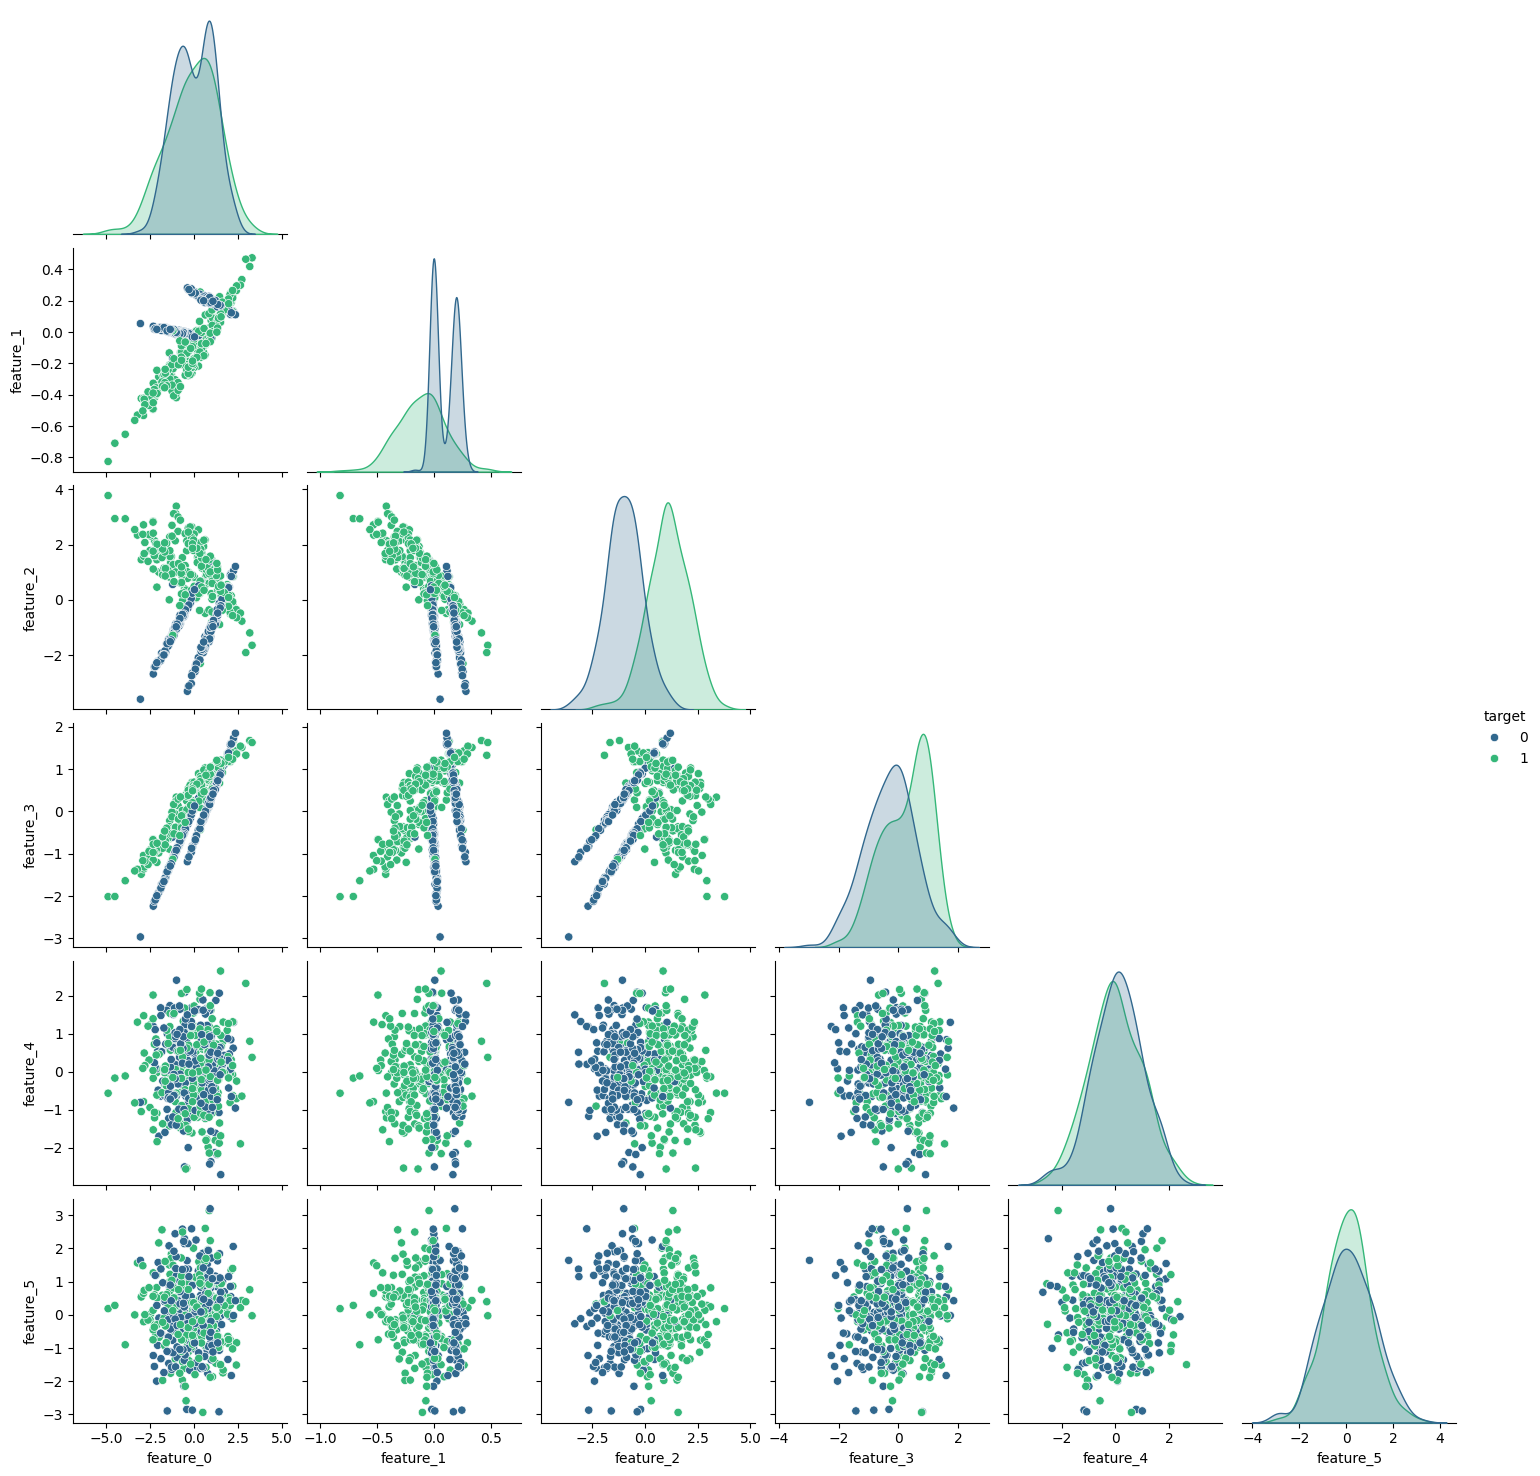

<Figure size 640x480 with 0 Axes>

In [10]:
sns.pairplot(
    df, 
    vars=["feature_0", "feature_1", "feature_2", "feature_3", "feature_4", "feature_5"], 
    hue="target", 
    palette="viridis",
    corner=True 
)
plt.show()
plt.tight_layout()


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
svm_model_rbf = SVC(
    C=0.1,
    kernel="rbf",
    gamma="scale",
    random_state=42
)

svm_model_rbf.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [14]:
y_pred_rbf = svm_model_rbf.predict(X_test_scaled)

y_pred_rbf

array([1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0])

In [15]:
accuracy = accuracy_score(y_test, y_pred_rbf)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rbf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rbf))

train_accuracy = svm_model_rbf.score(X_train_scaled, y_train)
test_accuracy = svm_model_rbf.score(X_test_scaled, y_test)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        46
           1       0.90      0.87      0.89        54

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100


Confusion Matrix:
[[41  5]
 [ 7 47]]
Training Accuracy: 0.9150
Testing Accuracy:  0.8800


In [16]:
svm_model_poly = SVC(
    C=0.1,
    degree=3,
    kernel="poly",
    gamma="scale",
    random_state=42
)

svm_model_poly.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
y_pred_poly = svm_model_poly.predict(X_test_scaled)

y_pred_poly

array([1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0])

In [18]:
accuracy = accuracy_score(y_test, y_pred_poly)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_poly))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_poly))

train_accuracy = svm_model_poly.score(X_train_scaled, y_train)
test_accuracy = svm_model_poly.score(X_test_scaled, y_test)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83        46
           1       0.89      0.78      0.83        54

    accuracy                           0.83       100
   macro avg       0.83      0.83      0.83       100
weighted avg       0.84      0.83      0.83       100


Confusion Matrix:
[[41  5]
 [12 42]]
Training Accuracy: 0.8875
Testing Accuracy:  0.8300


In [19]:
svm_model_linear = SVC(
    C=0.1,
    kernel="linear",
    random_state=42
)

svm_model_linear.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [20]:
y_pred_linear = svm_model_linear.predict(X_test_scaled)

y_pred_linear

array([1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0])

In [21]:
accuracy = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy: {accuracy}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_linear))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_linear))

train_accuracy = svm_model_linear.score(X_train_scaled, y_train)
test_accuracy = svm_model_linear.score(X_test_scaled, y_test)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.93      0.84        46
           1       0.93      0.76      0.84        54

    accuracy                           0.84       100
   macro avg       0.85      0.85      0.84       100
weighted avg       0.86      0.84      0.84       100


Confusion Matrix:
[[43  3]
 [13 41]]
Training Accuracy: 0.8975
Testing Accuracy:  0.8400
